# 📊 Diabetes Prediction Dataset - Exploratory Data Analysis

This notebook performs comprehensive EDA on the diabetes prediction dataset.

**Dataset Source:** [Kaggle - Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)

## Setup & Imports

In [1]:
# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print('📍 Running in Google Colab')
except ImportError:
    IN_COLAB = False
    print('📍 Running locally')

📍 Running locally


In [2]:
# Install required packages (only needed in Colab)
if IN_COLAB:
    !pip install -q kaggle

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Set plotting style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')  # Fallback for older matplotlib
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Create output directories
os.makedirs('out/plots', exist_ok=True)
os.makedirs('out/tables', exist_ok=True)
os.makedirs('data', exist_ok=True)

print('✅ Setup complete!')

✅ Setup complete!


## Load Dataset

**For Google Colab:** Upload your `kaggle.json` file when prompted, OR manually upload the CSV file.

In [4]:
# Download dataset from Kaggle (for Colab)
if IN_COLAB:
    # Check if dataset already exists
    if not os.path.exists('data/diabetes_prediction_dataset.csv'):
        print('📥 Downloading dataset from Kaggle...')
        
        # Install kagglehub
        !pip install -q kagglehub
        
        import kagglehub
        
        # Download dataset directly (no authentication needed for public datasets)
        path = kagglehub.dataset_download('iammustafatz/diabetes-prediction-dataset')
        print(f'📁 Dataset downloaded to: {path}')
        
        # Copy to data folder
        import shutil
        src_file = os.path.join(path, 'diabetes_prediction_dataset.csv')
        shutil.copy(src_file, 'data/diabetes_prediction_dataset.csv')
        print('✅ Dataset copied to data/diabetes_prediction_dataset.csv')
    else:
        print('✅ Dataset already exists!')

In [5]:
# Load the dataset
df = pd.read_csv('data/diabetes_prediction_dataset.csv')

# Save summary statistics
summary_stats = df.describe()
summary_stats.to_csv('out/tables/summary_statistics.csv')
print('✅ Saved summary statistics to out/tables/summary_statistics.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nFirst 5 rows:')
df.head()

✅ Saved summary statistics to out/tables/summary_statistics.csv
Dataset Shape: (100000, 9)

Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

First 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
# Quick data overview
print('Dataset Info:')
print('='*50)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


---
# 1. Summary Statistics

In [7]:
# Define numeric columns for analysis
numeric_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Compute summary statistics
summary_stats = pd.DataFrame({
    'Feature': numeric_cols,
    'Mean': [df[col].mean() for col in numeric_cols],
    'Std': [df[col].std() for col in numeric_cols],
    'Min': [df[col].min() for col in numeric_cols],
    'Median': [df[col].median() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    '% Missing': [df[col].isnull().sum() / len(df) * 100 for col in numeric_cols]
})

# Format for display
summary_stats_display = summary_stats.copy()
for col in ['Mean', 'Std', 'Min', 'Median', 'Max']:
    summary_stats_display[col] = summary_stats_display[col].round(2)
summary_stats_display['% Missing'] = summary_stats_display['% Missing'].round(2)

print('📊 Summary Statistics for Numeric Columns')
print('='*70)
print(summary_stats_display.to_string(index=False))

📊 Summary Statistics for Numeric Columns
            Feature   Mean   Std   Min  Median    Max  % Missing
                age  41.89 22.52  0.08   43.00  80.00        0.0
                bmi  27.32  6.64 10.01   27.32  95.69        0.0
        HbA1c_level   5.53  1.07  3.50    5.80   9.00        0.0
blood_glucose_level 138.06 40.71 80.00  140.00 300.00        0.0


In [8]:
# Gender distribution
gender_counts = df['gender'].value_counts()

print('\n👥 Gender Distribution')
print('='*40)
for gender, count in gender_counts.items():
    percentage = count / len(df) * 100
    print(f'{gender}: {count:,} ({percentage:.1f}%)')


👥 Gender Distribution
Female: 58,552 (58.6%)
Male: 41,430 (41.4%)
Other: 18 (0.0%)


In [9]:
# Smoking history counts
smoking_counts = df['smoking_history'].value_counts()

print('\n🚬 Smoking History Distribution')
print('='*40)
smoking_df = pd.DataFrame({
    'Category': smoking_counts.index,
    'Count': smoking_counts.values,
    'Percentage': (smoking_counts.values / len(df) * 100).round(2)
})
print(smoking_df.to_string(index=False))


🚬 Smoking History Distribution
   Category  Count  Percentage
    No Info  35816       35.82
      never  35095       35.10
     former   9352        9.35
    current   9286        9.29
not current   6447        6.45
       ever   4004        4.00


In [10]:
# Diabetes prevalence
diabetes_counts = df['diabetes'].value_counts()
diabetes_prevalence = df['diabetes'].sum() / len(df) * 100

print('\n🩺 Diabetes Prevalence')
print('='*40)
print(f'Non-Diabetic (0): {diabetes_counts[0]:,} ({100-diabetes_prevalence:.2f}%)')
print(f'Diabetic (1): {diabetes_counts[1]:,} ({diabetes_prevalence:.2f}%)')
print(f'\n📊 Overall Diabetes Prevalence: {diabetes_prevalence:.2f}%')


🩺 Diabetes Prevalence
Non-Diabetic (0): 91,500 (91.50%)
Diabetic (1): 8,500 (8.50%)

📊 Overall Diabetes Prevalence: 8.50%


---
# 2. Correlation & Feature Insights

In [11]:
# Compute Pearson correlations between numeric variables and diabetes
correlations = {}
for col in numeric_cols:
    correlations[col] = df[col].corr(df['diabetes'])

# Sort by absolute correlation (highest to lowest)
sorted_correlations = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True))

print('📈 Pearson Correlations with Diabetes (sorted by |correlation|)')
print('='*55)
corr_df = pd.DataFrame({
    'Feature': sorted_correlations.keys(),
    'Correlation': [round(v, 4) for v in sorted_correlations.values()]
})
print(corr_df.to_string(index=False))

📈 Pearson Correlations with Diabetes (sorted by |correlation|)
            Feature  Correlation
blood_glucose_level       0.4196
        HbA1c_level       0.4007
                age       0.2580
                bmi       0.2144


In [12]:
# Save out/tables/correlation.json
with open('out/tables/correlation.json', 'w') as f:
    json.dump({k: round(v, 4) for k, v in sorted_correlations.items()}, f, indent=2)

print('✅ Saved out/tables/correlation.json')

✅ Saved out/tables/correlation.json


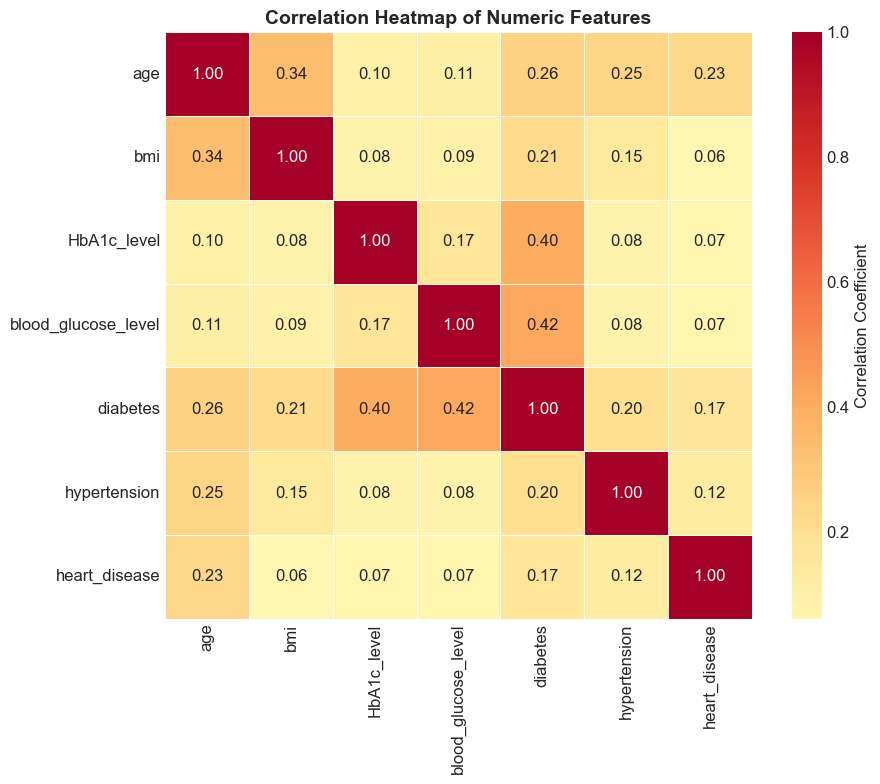

✅ Saved out/plots/correlation_heatmap.png


In [13]:
# Correlation Heatmap (all numeric features + diabetes)
all_numeric = numeric_cols + ['diabetes', 'hypertension', 'heart_disease']
corr_matrix = df[all_numeric].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('out/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved out/plots/correlation_heatmap.png')

---
# 3. Risk Group Statistics

In [14]:
# Define risk cohorts
cohorts = {
    'Elderly': df['age'] >= 60,
    'Overweight': df['bmi'] >= 30,
    'Hypertension': df['hypertension'] == 1,
    'Heart Disease': df['heart_disease'] == 1,
    'High Glucose': df['blood_glucose_level'] >= 180,
    'Smokers': df['smoking_history'].isin(['current', 'ever', 'former'])
}

# Calculate statistics for each cohort
risk_groups = []
for cohort_name, condition in cohorts.items():
    subset = df[condition]
    n = len(subset)
    diabetes_pct = subset['diabetes'].sum() / n * 100 if n > 0 else 0
    risk_groups.append({
        'Cohort': cohort_name,
        'Condition': {
            'Elderly': 'age >= 60',
            'Overweight': 'BMI >= 30',
            'Hypertension': 'hypertension = 1',
            'Heart Disease': 'heart_disease = 1',
            'High Glucose': 'blood_glucose_level >= 180',
            'Smokers': 'smoking_history in {current, ever, former}'
        }[cohort_name],
        'N': n,
        'Diabetes %': round(diabetes_pct, 2)
    })

risk_groups_df = pd.DataFrame(risk_groups)

print('⚠️ Risk Group Statistics')
print('='*70)
print(risk_groups_df.to_string(index=False))

⚠️ Risk Group Statistics
       Cohort                                  Condition     N  Diabetes %
      Elderly                                  age >= 60 25055       19.68
   Overweight                                  BMI >= 30 23536       17.99
 Hypertension                           hypertension = 1  7485       27.90
Heart Disease                          heart_disease = 1  3942       32.14
 High Glucose                 blood_glucose_level >= 180 10877       36.08
      Smokers smoking_history in {current, ever, former} 22642       13.29


In [15]:
# Save out/tables/risk_groups.csv
risk_groups_df.to_csv('out/tables/risk_groups.csv', index=False)
print('✅ Saved out/tables/risk_groups.csv')

✅ Saved out/tables/risk_groups.csv


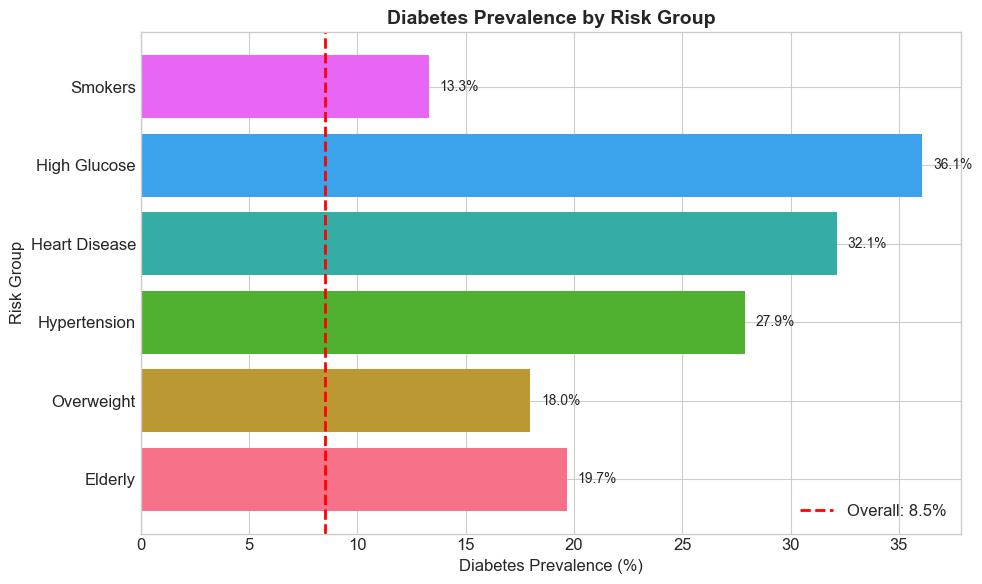

✅ Saved out/plots/risk_group_prevalence.png


In [16]:
# Visualize risk group diabetes prevalence
plt.figure(figsize=(10, 6))
bars = plt.barh(risk_groups_df['Cohort'], risk_groups_df['Diabetes %'], color=sns.color_palette('husl', len(risk_groups_df)))
plt.xlabel('Diabetes Prevalence (%)', fontsize=12)
plt.ylabel('Risk Group', fontsize=12)
plt.title('Diabetes Prevalence by Risk Group', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, risk_groups_df['Diabetes %']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontsize=10)

plt.axvline(x=diabetes_prevalence, color='red', linestyle='--', linewidth=2, label=f'Overall: {diabetes_prevalence:.1f}%')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('out/plots/risk_group_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved out/plots/risk_group_prevalence.png')

---
# 4. Feature Distributions

## 4.1 Histograms

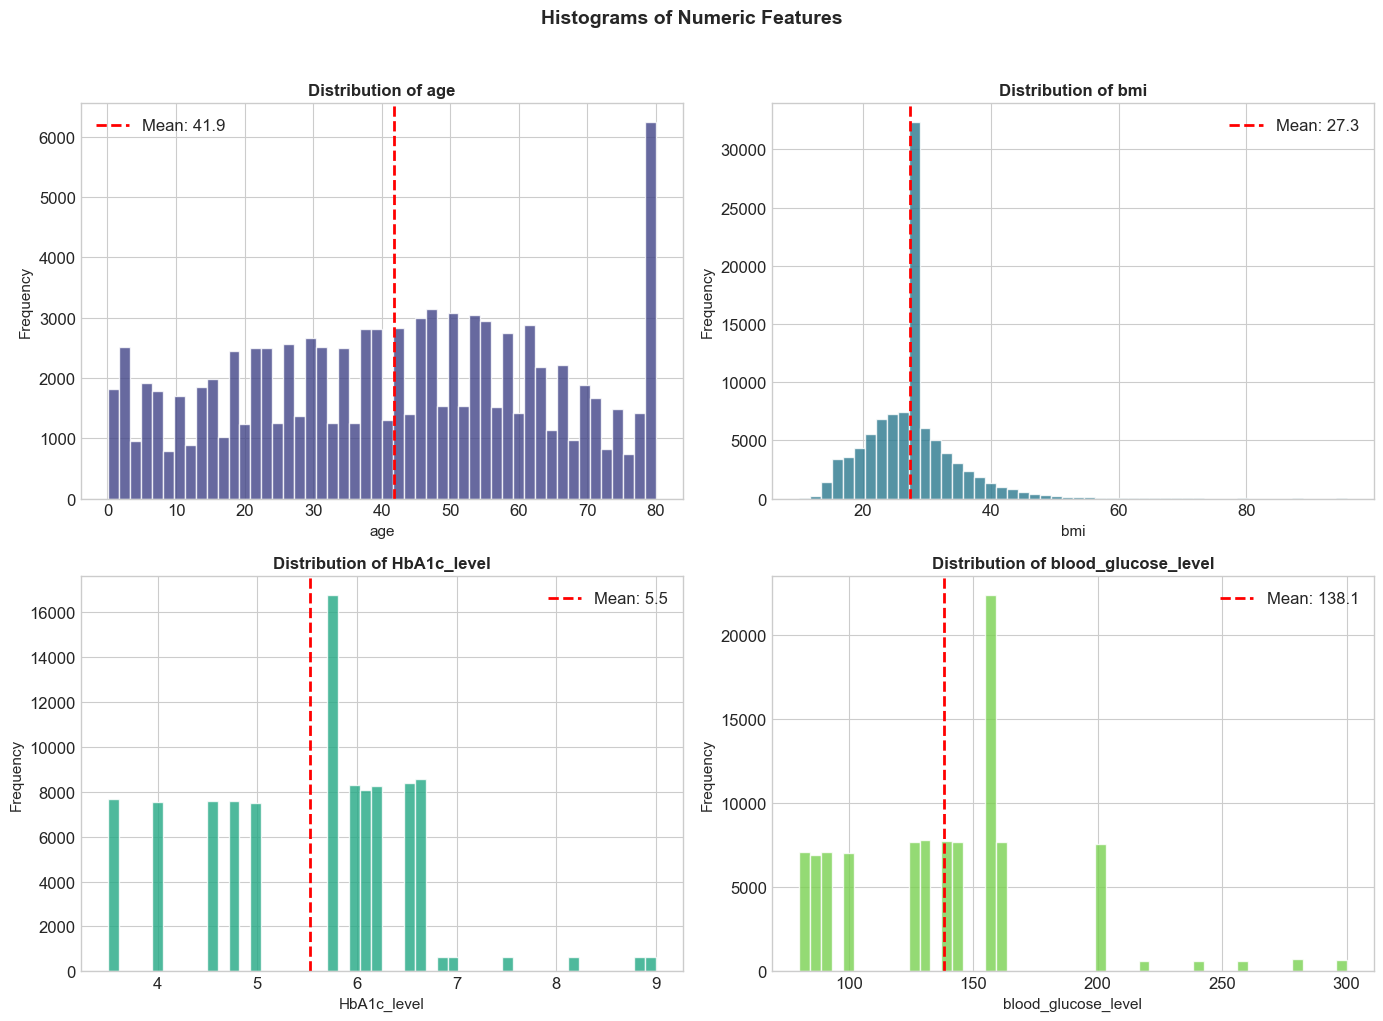

✅ Saved out/plots/histograms.png


In [17]:
# Histograms of numeric features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = sns.color_palette('viridis', 4)

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    ax.hist(df[col], bins=50, color=colors[idx], edgecolor='white', alpha=0.8)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    
    # Add mean line
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax.legend()

plt.suptitle('Histograms of Numeric Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('out/plots/histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved out/plots/histograms.png')

## 4.2 Boxplots by Diabetes Status

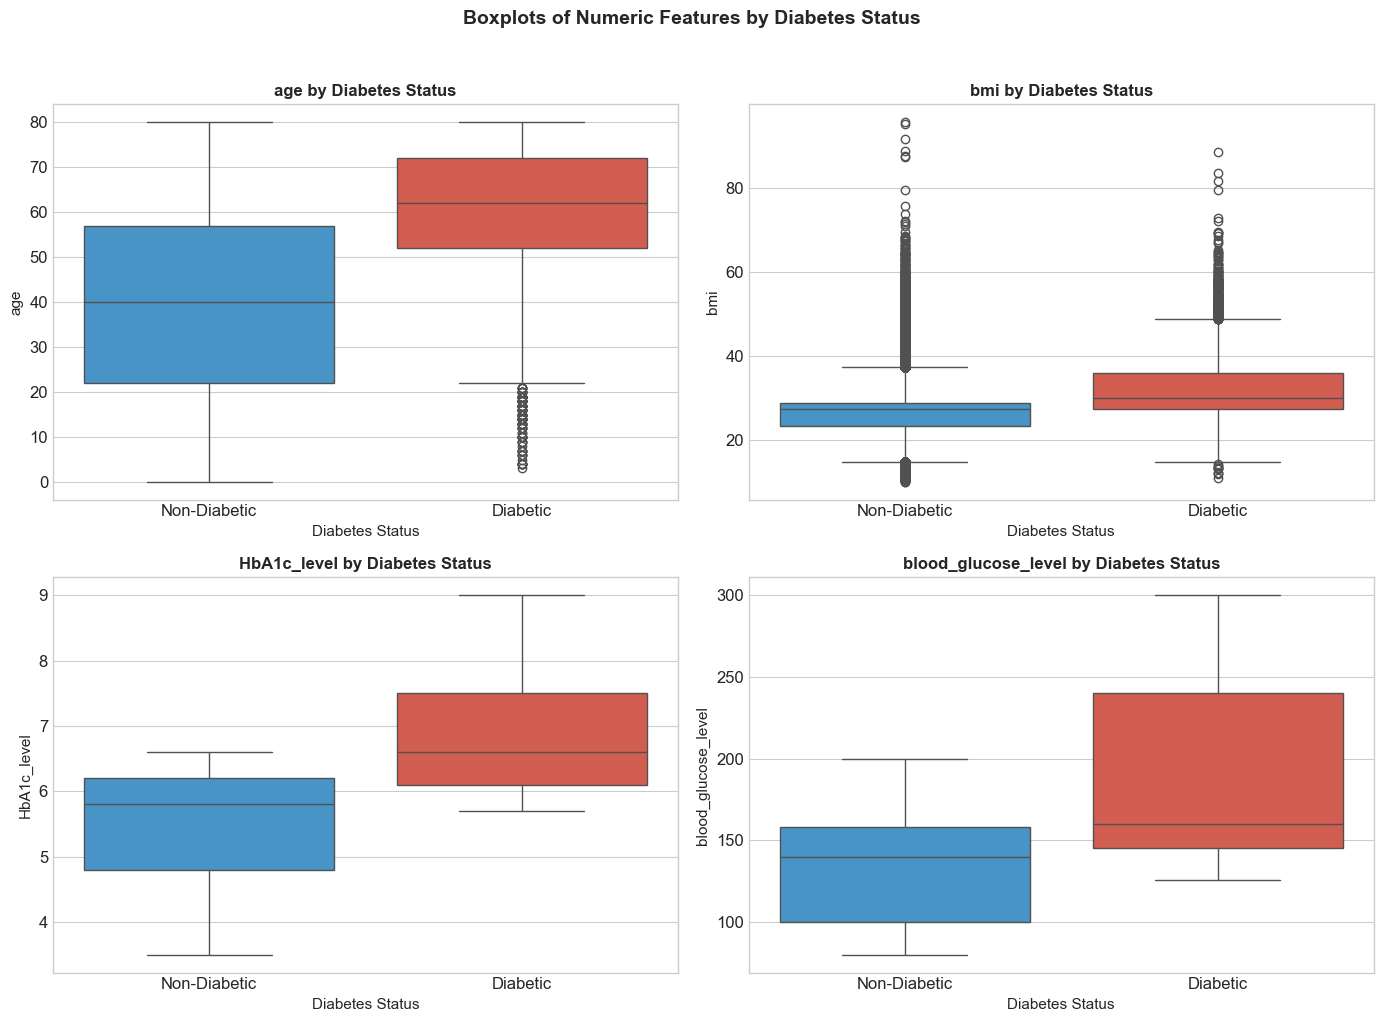

✅ Saved out/plots/boxplots_by_diabetes.png


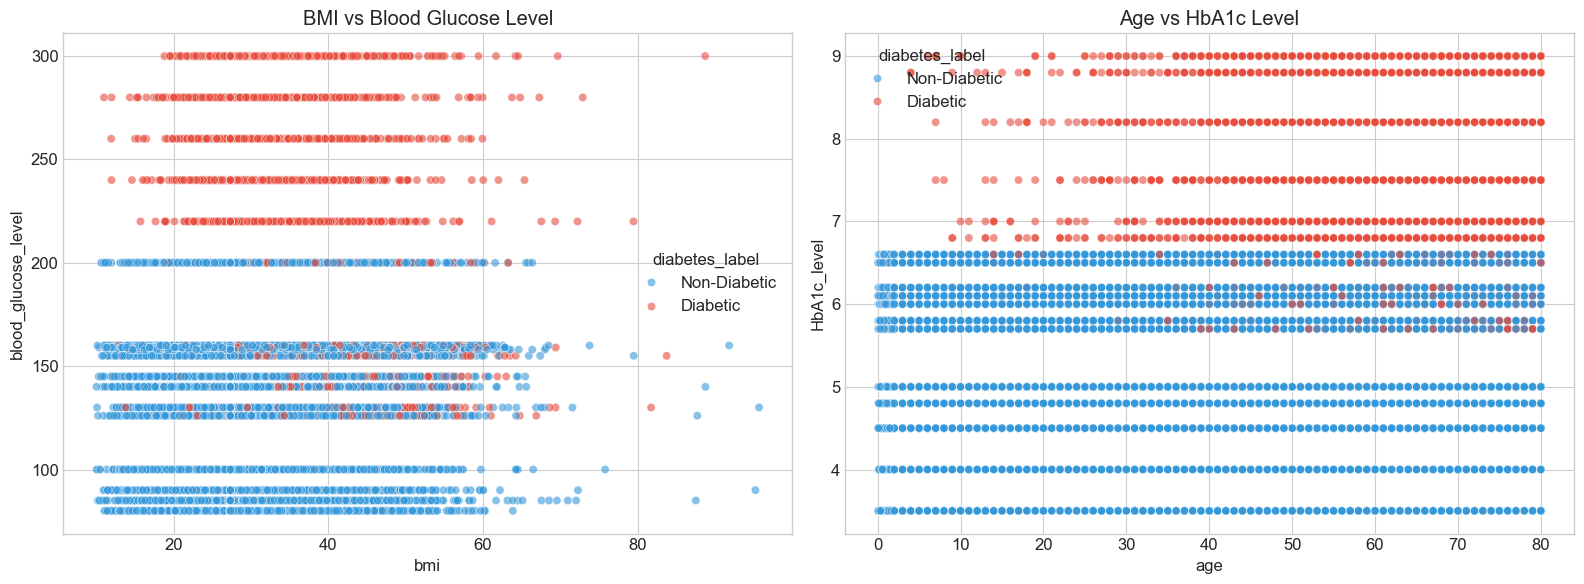

✅ Saved out/plots/scatter_plots.png


In [18]:
# Boxplots of numeric features grouped by diabetes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

palette = {'Non-Diabetic': '#3498db', 'Diabetic': '#e74c3c'}
df['diabetes_label'] = df['diabetes'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    sns.boxplot(data=df, x='diabetes_label', y=col, ax=ax, palette=palette, hue='diabetes_label', legend=False)
    ax.set_xlabel('Diabetes Status', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.set_title(f'{col} by Diabetes Status', fontsize=12, fontweight='bold')

plt.suptitle('Boxplots of Numeric Features by Diabetes Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('out/plots/boxplots_by_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved out/plots/boxplots_by_diabetes.png')
# Scatter Plots: BMI vs Glucose and Age vs HbA1c
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BMI vs Glucose
sns.scatterplot(data=df, x='bmi', y='blood_glucose_level', hue='diabetes_label', alpha=0.6, ax=axes[0], palette=palette)
axes[0].set_title('BMI vs Blood Glucose Level')

# Age vs HbA1c
sns.scatterplot(data=df, x='age', y='HbA1c_level', hue='diabetes_label', alpha=0.6, ax=axes[1], palette=palette)
axes[1].set_title('Age vs HbA1c Level')

plt.tight_layout()
plt.savefig('out/plots/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved out/plots/scatter_plots.png')


## 4.3 Smoking History vs Diabetes Prevalence

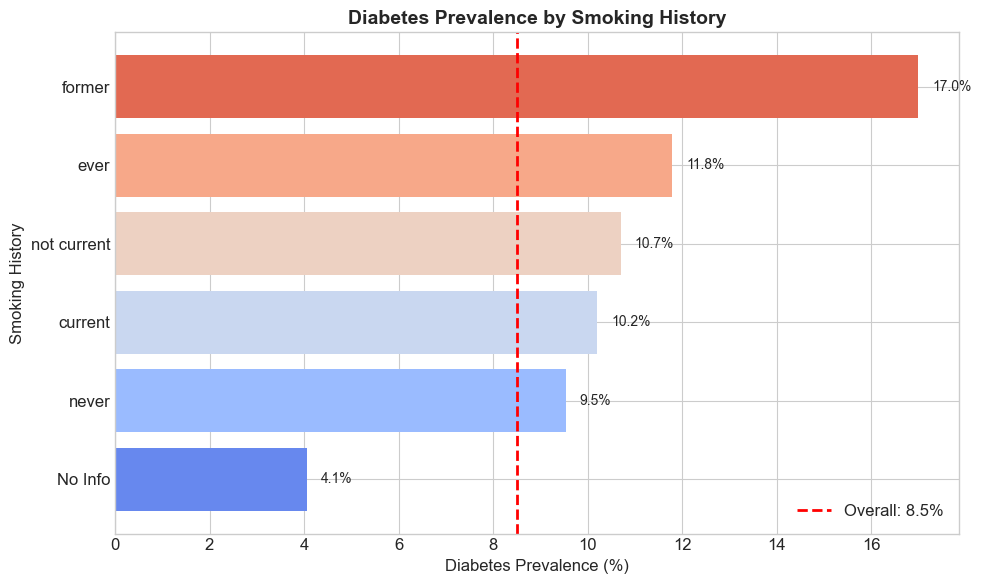

✅ Saved out/plots/smoking_diabetes_prevalence.png


In [19]:
# Bar chart of smoking history vs diabetes prevalence
smoking_diabetes = df.groupby('smoking_history').agg(
    total=('diabetes', 'count'),
    diabetic=('diabetes', 'sum')
).reset_index()

smoking_diabetes['prevalence'] = smoking_diabetes['diabetic'] / smoking_diabetes['total'] * 100
smoking_diabetes = smoking_diabetes.sort_values('prevalence', ascending=True)

plt.figure(figsize=(10, 6))
colors = sns.color_palette('coolwarm', len(smoking_diabetes))
bars = plt.barh(smoking_diabetes['smoking_history'], smoking_diabetes['prevalence'], color=colors)

plt.xlabel('Diabetes Prevalence (%)', fontsize=12)
plt.ylabel('Smoking History', fontsize=12)
plt.title('Diabetes Prevalence by Smoking History', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, smoking_diabetes['prevalence']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontsize=10)

# Add overall prevalence line
plt.axvline(x=diabetes_prevalence, color='red', linestyle='--', linewidth=2, label=f'Overall: {diabetes_prevalence:.1f}%')
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig('out/plots/smoking_diabetes_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved out/plots/smoking_diabetes_prevalence.png')

---
# 📋 Summary

This EDA has covered:

1. **Summary Statistics** - Computed mean, std, min, median, max, and % missing for numeric features  
2. **Correlation Analysis** - Identified features most correlated with diabetes (saved to `correlation.json`)  
3. **Risk Group Analysis** - Calculated diabetes prevalence across different risk cohorts (saved to `risk_groups.csv`)  
4. **Visualizations** - Generated histograms, boxplots, and bar charts (saved to `out/plots/`)

### Key Findings:
- Blood glucose level and HbA1c level show the strongest correlations with diabetes
- High glucose (>=180) and elderly (>=60) groups have significantly higher diabetes prevalence
- Smoking history shows varying impact on diabetes prevalence

In [20]:
# Final output summary
print('\n' + '='*60)
print('📁 OUTPUT FILES GENERATED:')
print('='*60)
print('├── correlation.json')
print('├── risk_groups.csv')
print('└── out/plots/')
print('    ├── correlation_heatmap.png')
print('    ├── risk_group_prevalence.png')
print('    ├── histograms.png')
print('    ├── boxplots_by_diabetes.png')
print('    └── smoking_diabetes_prevalence.png')
print('\n✅ EDA Complete!')


📁 OUTPUT FILES GENERATED:
├── correlation.json
├── risk_groups.csv
└── out/plots/
    ├── correlation_heatmap.png
    ├── risk_group_prevalence.png
    ├── histograms.png
    ├── boxplots_by_diabetes.png
    └── smoking_diabetes_prevalence.png

✅ EDA Complete!


In [21]:
# Download outputs (for Colab)
if IN_COLAB:
    from google.colab import files
    import shutil
    
    # Create a zip of all outputs
    shutil.make_archive('eda_outputs', 'zip', '.', 'out')
    
    print('📥 Download your outputs:')
    files.download('correlation.json')
    files.download('risk_groups.csv')
    files.download('eda_outputs.zip')